### Cell 1 — Config (edit this to switch index) - folder/file path

In [4]:
import os
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# ============ CONFIG — only this block changes per index ============
INDEX_NAME = "TXx"      # folder name under indices/: TXx, RX1Day, RX5Day, CDD, WSDI
VAR_NAME = "tasmax"     # variable inside the .nc file: tasmax, rx1dayETCCDI, rx5dayETCCDI, cddETCCDI, wsdiETCCDI
UNITS = "°C"           # °C, mm, or days

input_dir = "/mnt/wcs-s2-d4/etccdi_extreme_indices/output"
output_dir = f"/mnt/wcs-s2-d4/etccdi_extreme_indices/plots/india/{INDEX_NAME}"
shapefile_path = "/mnt/wcs-s2-d3/abbas/shapefiles/geoBoundaries-IND-ADM1-all/geoBoundaries-IND-ADM1.shp"
# =======================================================================

baseline_start = 1985
baseline_end = 2004
future_periods = [(2021, 2040), (2040, 2059), (2060, 2079), (2070, 2089)]
scenarios = ["g4", "rcp45"]
colors = {"g4": "#3a85c8", "rcp45": "#e03030"}
box_width = 0.15
group_gap = 1.4

os.makedirs(output_dir, exist_ok=True)
country_shape = gpd.read_file(shapefile_path)

def clip_to_country(da):
    # convert 0-360 longitude to -180 to 180 if necessary
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180)).sortby("lon")
    da = da.rio.write_crs("EPSG:4326", inplace=False)
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return da.rio.clip(country_shape.geometry, country_shape.crs, all_touched=True)

models = sorted(p.name for p in Path(input_dir).iterdir() if p.is_dir())

### Cell 2 — Plot each model separately

Saved plot for CSIRO-Mk3L-1-2 to /mnt/wcs-s2-d4/etccdi_extreme_indices/plots/india/TXx


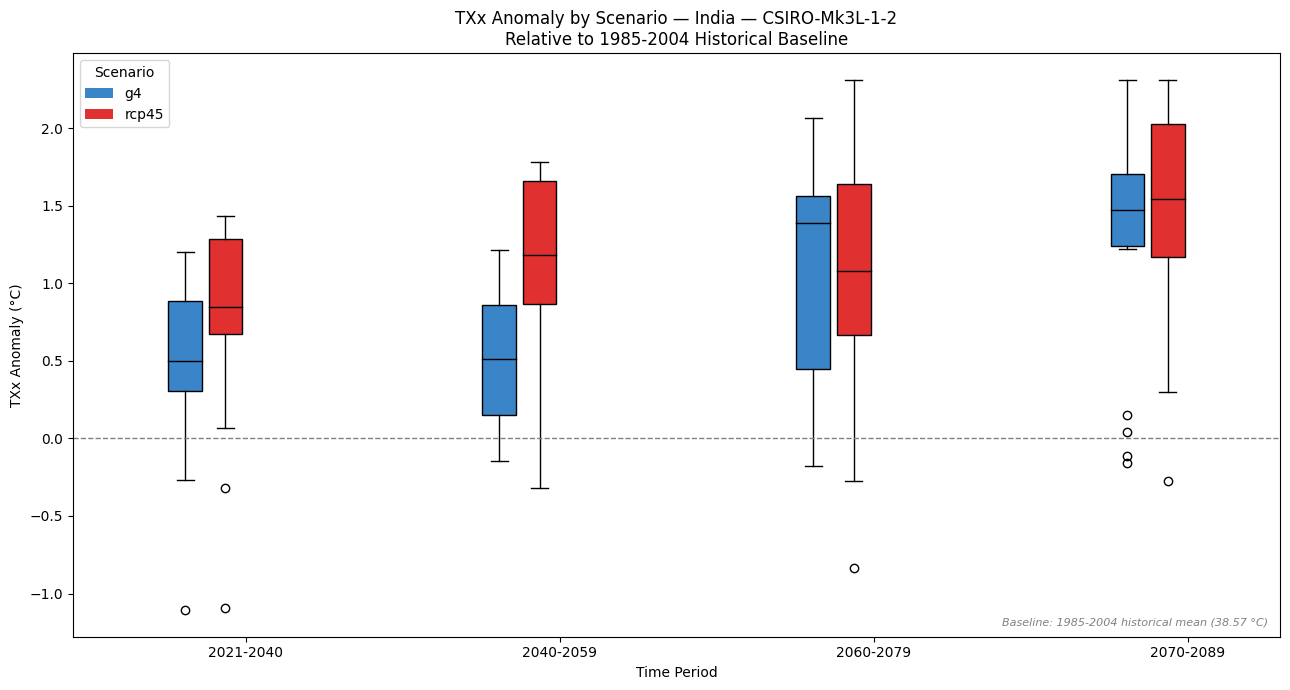

Saved plot for HadGEM2-ES to /mnt/wcs-s2-d4/etccdi_extreme_indices/plots/india/TXx


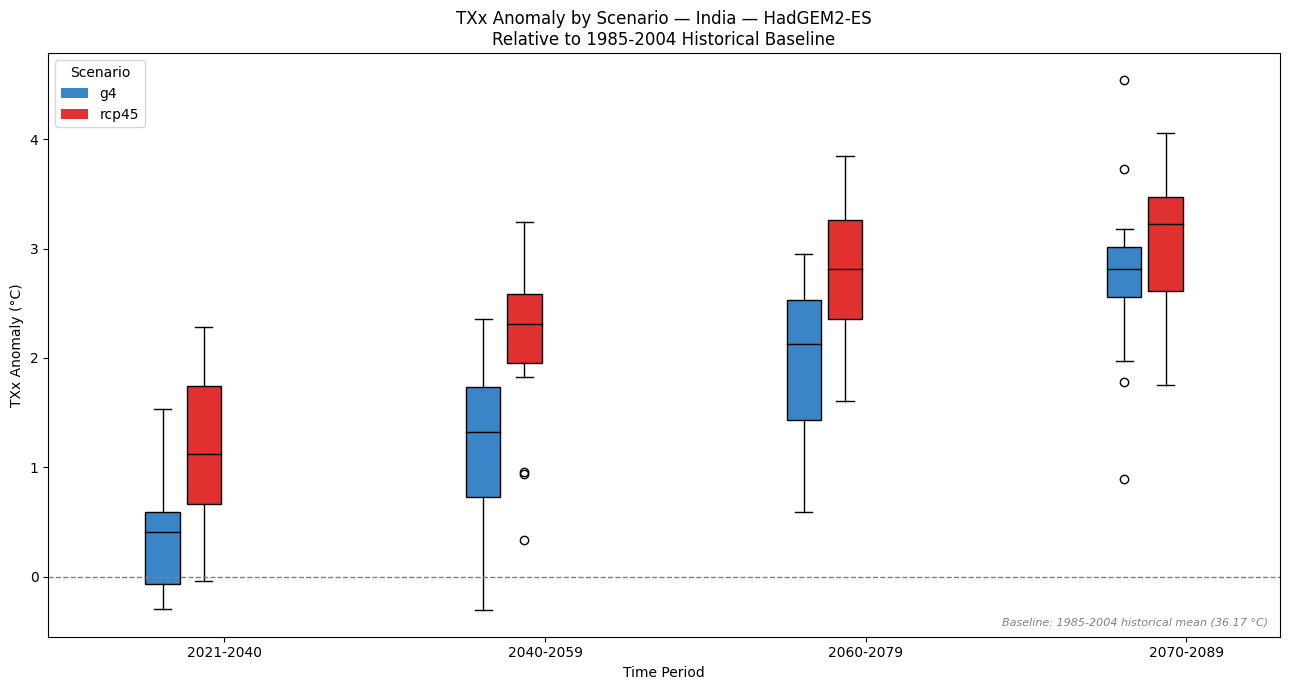

In [5]:
for model in models:

    scenario_files = {}
    for scenario in scenarios:
        found = list(Path(input_dir).glob(model + "/indices/" + INDEX_NAME + "/" + scenario + "/*.nc"))
        if len(found) > 0:
            scenario_files[scenario] = found[0]

    if "rcp45" not in scenario_files:
        print("Skipping " + model + ": no rcp45 file found")
        continue

    # baseline: clip to country, average over space, then average over years
    da = xr.open_dataset(scenario_files["rcp45"], decode_timedelta=False)[VAR_NAME]
    yearly = clip_to_country(da).astype(float).mean(dim=("lat", "lon"))
    baseline_mean = yearly.sel(time=slice(str(baseline_start), str(baseline_end))).mean(dim="time").values

    fig, ax = plt.subplots(figsize=(13, 7))
    period_position = 0

    for start_year, end_year in future_periods:
        scenario_position = 0
        for scenario in scenarios:
            if scenario not in scenario_files:
                scenario_position += 1
                continue

            da = xr.open_dataset(scenario_files[scenario], decode_timedelta=False)[VAR_NAME]
            yearly = clip_to_country(da).astype(float).mean(dim=("lat", "lon"))
            period_values = yearly.sel(time=slice(str(start_year), str(end_year))).values
            anomaly = period_values - baseline_mean

            offset = (scenario_position - 1.5) * (box_width + 0.03)
            x_pos = period_position + offset
            box = ax.boxplot(anomaly, positions=[x_pos], widths=box_width, patch_artist=True)
            box["boxes"][0].set_facecolor(colors[scenario])
            box["medians"][0].set_color("black")
            scenario_position += 1

        period_position += group_gap

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

    period_labels = [f"{s}-{e}" for s, e in future_periods]
    ax.set_xticks([i * group_gap for i in range(len(future_periods))])
    ax.set_xticklabels(period_labels)
    ax.set_xlabel("Time Period")
    ax.set_ylabel(f"{INDEX_NAME} Anomaly ({UNITS})")
    ax.set_title(f"{INDEX_NAME} Anomaly by Scenario \u2014 India \u2014 " + model +
                 "\nRelative to " + str(baseline_start) + "-" + str(baseline_end) + " Historical Baseline")
    ax.text(0.99, 0.02, "Baseline: " + str(baseline_start) + "-" + str(baseline_end) + " historical mean (" +
            str(round(float(baseline_mean), 2)) + f" {UNITS})",
            transform=ax.transAxes, ha="right", fontsize=8, style="italic", color="gray")

    legend_boxes = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[s]) for s in scenarios]
    ax.legend(legend_boxes, scenarios, title="Scenario", loc="upper left")

    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, f"{model}_{INDEX_NAME.lower()}_anomaly.png"), dpi=300, bbox_inches="tight")
    print(f"Saved plot for {model} to {output_dir}")
    plt.show()
    plt.close()

### Cell 3 — Cumulative (all models pooled)

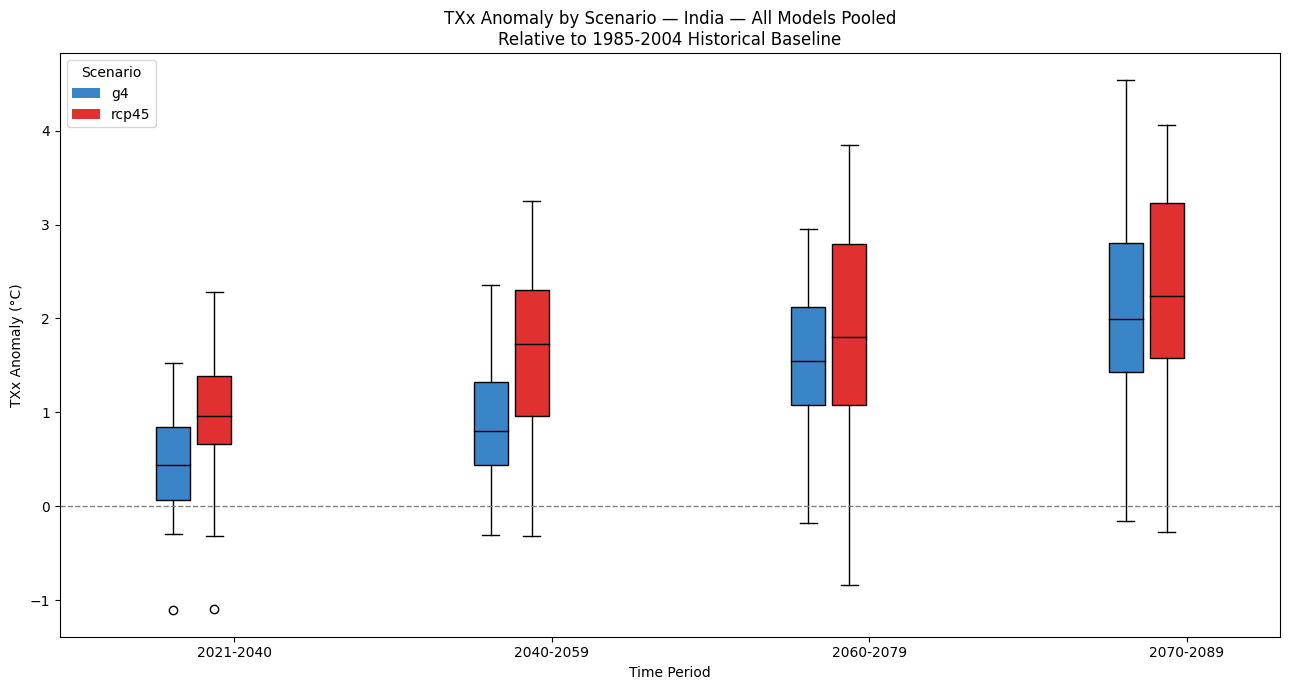

In [6]:
model_scenario_files = {}
model_baseline = {}

for model in models:
    scenario_files = {}
    for scenario in scenarios:
        found = list(Path(input_dir).glob(model + "/indices/" + INDEX_NAME + "/" + scenario + "/*.nc"))
        if len(found) > 0:
            scenario_files[scenario] = found[0]

    if "rcp45" not in scenario_files:
        print("Skipping " + model + ": no rcp45 file found")
        continue

    da = xr.open_dataset(scenario_files["rcp45"], decode_timedelta=False)[VAR_NAME]
    yearly = clip_to_country(da).astype(float).mean(dim=("lat", "lon"))
    model_scenario_files[model] = scenario_files
    model_baseline[model] = yearly.sel(time=slice(str(baseline_start), str(baseline_end))).mean(dim="time").values

fig, ax = plt.subplots(figsize=(13, 7))
period_position = 0

for start_year, end_year in future_periods:
    scenario_position = 0
    for scenario in scenarios:
        pooled_anomaly = []
        for model in model_scenario_files:
            scenario_files = model_scenario_files[model]
            if scenario not in scenario_files:
                continue
            da = xr.open_dataset(scenario_files[scenario], decode_timedelta=False)[VAR_NAME]
            yearly = clip_to_country(da).astype(float).mean(dim=("lat", "lon"))
            period_values = yearly.sel(time=slice(str(start_year), str(end_year))).values
            pooled_anomaly.extend(period_values - model_baseline[model])

        if len(pooled_anomaly) == 0:
            scenario_position += 1
            continue

        offset = (scenario_position - 1.5) * (box_width + 0.03)
        x_pos = period_position + offset
        box = ax.boxplot(pooled_anomaly, positions=[x_pos], widths=box_width, patch_artist=True)
        box["boxes"][0].set_facecolor(colors[scenario])
        box["medians"][0].set_color("black")
        scenario_position += 1

    period_position += group_gap

ax.axhline(0, color="gray", linestyle="--", linewidth=1)

period_labels = [f"{s}-{e}" for s, e in future_periods]
ax.set_xticks([i * group_gap for i in range(len(future_periods))])
ax.set_xticklabels(period_labels)
ax.set_xlabel("Time Period")
ax.set_ylabel(f"{INDEX_NAME} Anomaly ({UNITS})")
ax.set_title(f"{INDEX_NAME} Anomaly by Scenario \u2014 India \u2014 All Models Pooled\n"
             "Relative to " + str(baseline_start) + "-" + str(baseline_end) + " Historical Baseline")

legend_boxes = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[s]) for s in scenarios]
ax.legend(legend_boxes, scenarios, title="Scenario", loc="upper left")

plt.tight_layout()
# plt.savefig(os.path.join(output_dir, f"all_models_pooled_{INDEX_NAME.lower()}_anomaly.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()